# Housing Features and Target

**Purpose.** ACS DP04 supply, density, age, rooms, tenure, occupancy, value, mortgage, and cost-burden features.

This notebook is a read-only diagnostic consumer of the current `feature.*` layer. All transformations and canonical ACS mappings are owned by `src/cli/build_database.py`.

## Setup and current feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "housing_predict.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB_PATH = ROOT / "data" / "housing_predict.duckdb"
if not DB_PATH.exists():
    raise FileNotFoundError("Run `python -m src.cli.build_database` from the project root first.")

con = duckdb.connect(str(DB_PATH), read_only=True)
FEATURE_TABLES = ['county_housing']

available = {row[0] for row in con.execute(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'feature'"
).fetchall()}
missing = sorted(set(FEATURE_TABLES) - available)
if missing:
    raise RuntimeError(
        f"Database is missing current feature tables {missing}. "
        "Run `python -m src.cli.build_database` to rebuild it."
    )

registry_available = "canonical_feature_registry" in available
if registry_available:
    placeholders = ", ".join("?" for _ in FEATURE_TABLES)
    source_tables = [{
        "county_economic_annual": "dp03",
        "county_social_annual": "dp02",
        "county_housing": "dp04",
    }.get(table) for table in FEATURE_TABLES]
    source_tables = [table for table in source_tables if table]
    if source_tables:
        source_placeholders = ", ".join("?" for _ in source_tables)
        registry = con.execute(
            f"SELECT feature_name, acs_table, unit, min(year) AS first_year, "
            f"max(year) AS last_year, count(*) AS mapped_years "
            f"FROM feature.canonical_feature_registry WHERE acs_table IN ({source_placeholders}) "
            f"GROUP BY 1,2,3 ORDER BY 2,1",
            source_tables,
        ).df()
    else:
        registry = pd.DataFrame(columns=["feature_name", "acs_table", "unit", "first_year", "last_year", "mapped_years"])
else:
    registry = pd.DataFrame()
display(registry)

,feature_name,acs_table,unit,first_year,last_year,mapped_years
0,average_owner_household_size,dp04,people,2010,2024,15
1,average_renter_household_size,dp04,people,2010,2024,15
2,built_1939_or_earlier_pct,dp04,percent,2010,2024,15
3,detached_single_unit_pct,dp04,percent,2010,2024,15
4,gross_rent_30_to_34_9_pct,dp04,percent,2010,2024,15
5,gross_rent_35_plus_pct,dp04,percent,2010,2024,15
6,homeowner_vacancy_rate_pct,dp04,percent,2010,2024,15
7,householder_moved_1989_or_earlier_pct,dp04,percent,2019,2024,6
8,housing_units,dp04,housing units,2010,2024,15
9,large_multifamily_20_plus_units_pct,dp04,percent,2010,2024,15


## Table inventory and county-year grain

In [2]:
inventory = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    row_count, distinct_keys, min_year, max_year = con.execute(
        f"SELECT count(*), count(DISTINCT (county_fips, year)), min(year), max(year) FROM feature.{table}"
    ).fetchone()
    inventory.append({
        "feature_table": table,
        "rows": row_count,
        "distinct_county_years": distinct_keys,
        "duplicate_county_years": row_count - distinct_keys,
        "first_year": min_year,
        "last_year": max_year,
        "feature_columns": len(schema) - len({"county_fips", "year", "county_name"} & set(schema["column_name"])),
    })
inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["duplicate_county_years"] == 0).all(), "Feature tables must be unique by county and year."

,feature_table,rows,distinct_county_years,duplicate_county_years,first_year,last_year,feature_columns
0,county_housing,48312,48312,0,2010,2024,21


## Completeness by feature and year

In [3]:
completeness = []
identifier_columns = {"county_fips", "year", "county_name"}
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    for column in [column for column in columns if column not in identifier_columns]:
        quoted = '"' + column.replace('"', '""') + '"'
        rows = con.execute(
            f"SELECT year, count(*) AS rows, count({quoted}) AS nonnull_rows "
            f"FROM feature.{table} GROUP BY year ORDER BY year"
        ).df()
        rows["feature_table"] = table
        rows["feature_name"] = column
        rows["completeness_pct"] = 100 * rows["nonnull_rows"] / rows["rows"]
        completeness.append(rows)
completeness = pd.concat(completeness, ignore_index=True)
display(completeness.groupby(["feature_table", "feature_name"], as_index=False).agg(
    first_available_year=("year", lambda s: completeness.loc[s.index][completeness.loc[s.index, "nonnull_rows"] > 0]["year"].min()),
    mean_completeness_pct=("completeness_pct", "mean"),
    minimum_completeness_pct=("completeness_pct", "min"),
).sort_values(["feature_table", "mean_completeness_pct"]))

,feature_table,feature_name,first_available_year,mean_completeness_pct,minimum_completeness_pct
7,county_housing,householder_moved_1989_or_earlier_pct,2019,40.000000,0.000000
17,county_housing,target_median_owner_occupied_home_value_2024_usd,2010,99.921351,99.813780
12,county_housing,owner_cost_30_to_34_9_pct,2010,99.929627,99.906832
13,county_housing,owner_cost_35_plus_pct,2010,99.929627,99.906832
0,county_housing,average_owner_household_size,2010,99.968952,99.968944
6,county_housing,homeowner_vacancy_rate_pct,2010,99.979304,99.968944
19,county_housing,with_mortgage_pct,2010,99.979304,99.968944
20,county_housing,without_mortgage_pct,2010,99.979304,99.968944
4,county_housing,gross_rent_30_to_34_9_pct,2010,99.991722,99.937927
5,county_housing,gross_rent_35_plus_pct,2010,99.991722,99.937927


## Distributions and range checks

In [4]:
summaries = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False, regex=True),
        "column_name",
    ].tolist()
    for column in [column for column in numeric if column != "year"]:
        q = '"' + column.replace('"', '""') + '"'
        values = con.execute(f"SELECT {q} FROM feature.{table} WHERE {q} IS NOT NULL").df().iloc[:, 0]
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        summaries.append({
            "feature_table": table, "feature_name": column, "count": len(values),
            "min": values.min(), "median": values.median(), "mean": values.mean(), "max": values.max(),
            "iqr_outliers": int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()),
            "outside_percent_range": int(((values < 0) | (values > 100)).sum()) if column.endswith("_pct") else np.nan,
        })
summaries = pd.DataFrame(summaries)
display(summaries)
assert summaries["outside_percent_range"].fillna(0).eq(0).all(), "Percentage feature outside [0, 100]."

,feature_table,feature_name,count,min,median,mean,max,iqr_outliers,outside_percent_range
0,county_housing,housing_units,48312,33.000000,12368.500000,42691.863781,3650466.00,6149,NaN
1,county_housing,vacant_housing_units_pct,48312,1.700000,15.500000,17.993362,88.30,2206,0.0
2,county_housing,homeowner_vacancy_rate_pct,48302,0.000000,1.700000,1.911205,26.40,1793,0.0
3,county_housing,rental_vacancy_rate_pct,48312,0.000000,6.200000,7.036370,70.60,2162,0.0
4,county_housing,detached_single_unit_pct,48312,0.600000,73.100000,72.168374,97.80,944,0.0
5,county_housing,large_multifamily_20_plus_units_pct,48312,0.000000,1.500000,2.732449,78.90,3368,0.0
6,county_housing,mobile_home_pct,48312,0.000000,10.400000,12.473224,63.50,670,0.0
7,county_housing,built_1939_or_earlier_pct,48312,0.000000,11.250000,14.962862,64.70,210,0.0
8,county_housing,median_rooms_per_unit,48311,2.400000,5.600000,5.613388,10.00,1371,NaN
9,county_housing,owner_occupied_pct,48312,0.000000,73.400000,72.185327,97.40,1503,0.0


## Correlation and redundancy

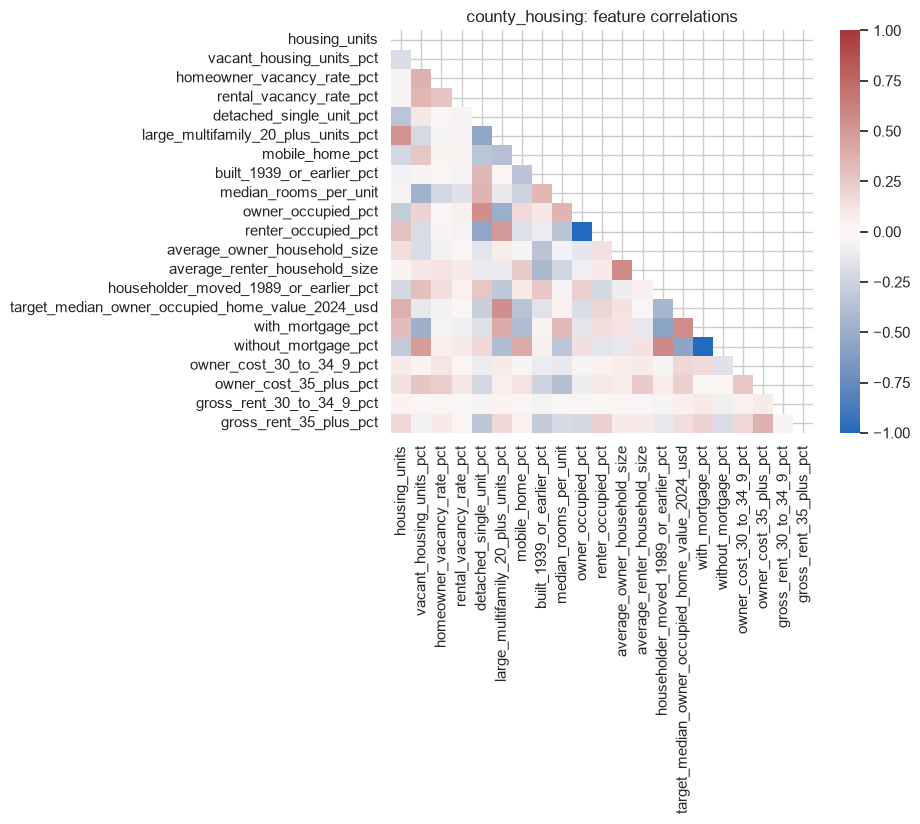

,feature_a,feature_b,correlation,abs_correlation
351,without_mortgage_pct,with_mortgage_pct,-1.000000,1.000000
219,renter_occupied_pct,owner_occupied_pct,-1.000000,1.000000
349,without_mortgage_pct,householder_moved_1989_or_earlier_pct,0.574962,0.574962
328,with_mortgage_pct,householder_moved_1989_or_earlier_pct,-0.574962,0.574962
263,average_renter_household_size,average_owner_household_size,0.565472,0.565472
350,without_mortgage_pct,target_median_owner_occupied_home_value_2024_usd,-0.557294,0.557294
329,with_mortgage_pct,target_median_owner_occupied_home_value_2024_usd,0.557294,0.557294
109,large_multifamily_20_plus_units_pct,detached_single_unit_pct,-0.551976,0.551976
299,target_median_owner_occupied_home_value_2024_usd,large_multifamily_20_plus_units_pct,0.540194,0.540194
193,owner_occupied_pct,detached_single_unit_pct,0.539859,0.539859


In [5]:
for table in FEATURE_TABLES:
    frame = con.execute(f"SELECT * FROM feature.{table}").df()
    numeric = frame.select_dtypes(include=np.number).drop(columns=["year"], errors="ignore")
    if numeric.shape[1] < 2:
        continue
    corr = numeric.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(corr)), max(6, 0.4 * len(corr))))
    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"{table}: feature correlations")
    plt.tight_layout()
    plt.show()

    pairs = corr.where(~mask).stack().rename("correlation").reset_index()
    pairs.columns = ["feature_a", "feature_b", "correlation"]
    display(pairs.assign(abs_correlation=pairs["correlation"].abs()).sort_values("abs_correlation", ascending=False).head(20))

## Temporal coverage and trends

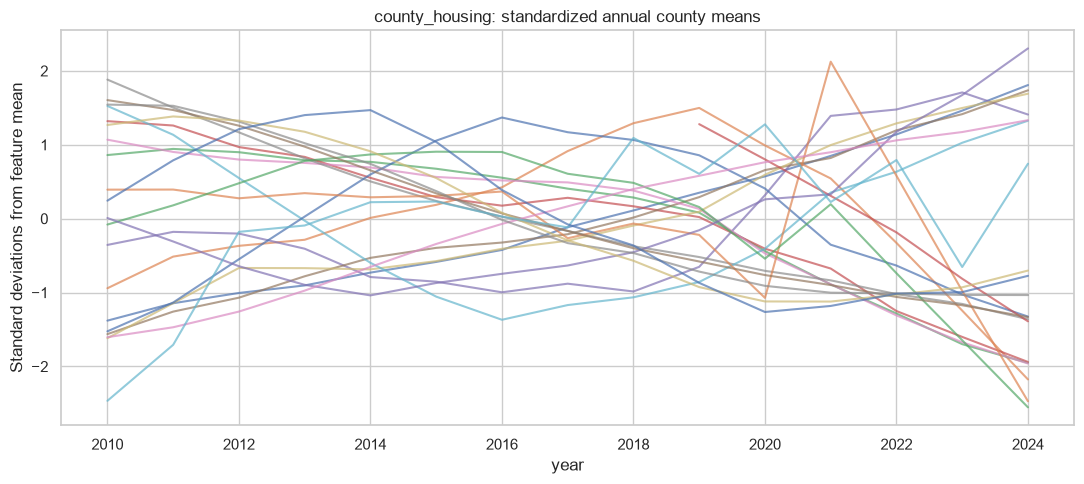

,year,housing_units,vacant_housing_units_pct,homeowner_vacancy_rate_pct,rental_vacancy_rate_pct,detached_single_unit_pct,large_multifamily_20_plus_units_pct,mobile_home_pct,built_1939_or_earlier_pct,median_rooms_per_unit,owner_occupied_pct,renter_occupied_pct,average_owner_household_size,average_renter_household_size,householder_moved_1989_or_earlier_pct,target_median_owner_occupied_home_value_2024_usd,with_mortgage_pct,without_mortgage_pct,owner_cost_30_to_34_9_pct,owner_cost_35_plus_pct,gross_rent_30_to_34_9_pct,gross_rent_35_plus_pct
0,2010,40829.588948,17.280161,2.288571,7.925054,72.105495,2.403384,12.911115,16.788916,5.512822,73.303198,26.696864,2.570453,2.412847,NaN,189688.698611,55.326770,44.673385,7.871792,23.927555,8.563241,36.517448
1,2011,41147.244645,17.604315,2.325000,7.885160,72.136728,2.467526,12.843092,16.421080,5.542285,73.017231,26.982831,2.570472,2.427637,NaN,184784.645028,55.041335,44.958665,7.860951,24.156695,8.602204,37.224371
2,2012,41334.798820,17.714747,2.305497,7.688730,72.132599,2.507203,12.800931,16.096088,5.571872,72.587892,27.412139,2.568575,2.444645,NaN,179613.658845,54.589907,45.410124,7.717676,24.045760,8.680813,37.770537
3,2013,41472.425023,17.776902,2.257826,7.599441,72.096430,2.568178,12.782335,15.755045,5.571748,72.164794,27.835206,2.569693,2.461841,NaN,175722.896053,53.986894,46.013168,7.521373,23.744921,8.685253,38.016827
4,2014,41706.411180,18.001273,2.248385,7.408385,72.028696,2.620683,12.757143,15.451832,5.570714,71.746925,28.253168,2.568792,2.466817,NaN,173514.963293,53.304472,46.695559,7.333706,23.220317,8.701460,38.104224
5,2015,41901.390373,18.134845,2.207329,7.232143,72.017609,2.649161,12.704596,15.194658,5.577640,71.411460,28.588602,2.569087,2.468938,NaN,176107.717236,52.644006,47.356025,7.086704,22.501522,8.701925,37.547050
6,2016,42120.075466,18.314534,2.154193,7.154658,71.992236,2.664286,12.684969,14.988975,5.588012,71.181863,28.818199,2.570047,2.468708,NaN,178028.510278,52.066894,47.933168,6.825940,21.567474,8.691429,36.703913
7,2017,42534.429814,18.685776,2.089255,7.226366,72.012795,2.688012,12.674224,14.801739,5.594814,71.327764,28.672236,2.559891,2.451957,NaN,179762.846032,51.561273,48.438727,6.614512,20.825606,8.683913,36.102298
8,2018,42840.823292,18.971553,2.036553,7.148944,71.994161,2.735559,12.629193,14.600652,5.607578,71.404627,28.595373,2.563088,2.444950,NaN,182545.890171,51.063199,48.936863,6.524464,20.278023,8.746194,35.732774
9,2019,43164.540994,19.128230,1.946785,7.050621,72.053075,2.793758,12.527174,14.458354,5.619224,71.556708,28.443323,2.560621,2.426317,17.287360,187145.926582,50.682293,49.317801,6.356015,19.570407,8.721180,35.076957


In [6]:
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False), "column_name"].tolist()
    numeric = [column for column in numeric if column != "year"]
    if not numeric:
        continue
    expressions = ", ".join(f'avg("{column}") AS "{column}"' for column in numeric)
    annual = con.execute(f"SELECT year, {expressions} FROM feature.{table} GROUP BY year ORDER BY year").df()
    normalized = annual.set_index("year").apply(lambda s: (s - s.mean()) / s.std() if s.std() else 0)
    fig, ax = plt.subplots(figsize=(11, 5))
    normalized.plot(ax=ax, legend=False, alpha=0.7)
    ax.set_title(f"{table}: standardized annual county means")
    ax.set_ylabel("Standard deviations from feature mean")
    plt.tight_layout()
    plt.show()
    display(annual)

con.close()

## Interpretation notes

- ACS values are five-year estimates associated with their release year. Adjacent years therefore contain overlapping survey periods. Five-year estimates are favored over one-year estimates in this project because the former offers complete annual data over the time period defined in the project's scope, while the latter does not.
- Monetary ACS features and the housing target are expressed in 2024 dollars.
- A null before a feature's `first_year` can indicate that ACS had not yet published a reconciled definition.
- `target_median_owner_occupied_home_value_2024_usd` is the official DP04 median, because DP04 does not publish a county average housing-unit value.
- The canonical registry and transactional build are the authority for cross-year compatibility.